In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
df = pd.read_csv("..\data\zomato.csv\zomato.csv")

In [3]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

### Removing phone number column as it is not required for analysis

In [5]:
df['phone']

0          080 42297555\r\n+91 9743772233
1                            080 41714161
2                          +91 9663487993
3                          +91 9620009302
4        +91 8026612447\r\n+91 9901210005
                       ...               
56247                        080 40301477
56248                      +91 8197675843
56249                                 NaN
56250                        080 49652769
56251                      +91 8071117272
Name: phone, Length: 56252, dtype: object

In [6]:
df['phone'].value_counts()

 ('Rated 4.0'                            412
 ('Rated 5.0'                            393
080 43334321                             216
 ('Rated 3.0'                            181
080 43334333                             167
                                        ... 
080 26539798\r\r\n+91 7619201123           1
+91 7406666414\r\r\n+91 8880404444         1
+91 8217793626\r\r\n+91 8375867011         1
 wand                                      1
but friendly staff\nFood is good too       1
Name: phone, Length: 17712, dtype: int64

In [7]:
df2 = df.copy()

In [8]:
df2.drop(columns=['phone'], inplace=True)

### Removing dish_liked column because more than 50% of the data is missing in this column

In [9]:
df['dish_liked'].value_counts()

 ('Rated 4.0'                                                                                                                                                                                                                   407
 ('Rated 5.0'                                                                                                                                                                                                                   328
Biryani                                                                                                                                                                                                                         182
 ('Rated 3.0'                                                                                                                                                                                                                   156
 ('Rated 1.0'                                                                           

In [10]:
df2.drop(columns=['dish_liked'], inplace=True)

### Removing "name" column as it is not required for analysis


In [11]:
df2.drop(columns= ['name'], inplace=True)

### Working with 'Address' and 'Location' columns to extract useful information

In [12]:
df[['address','location']]

,address,location
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Basavanagudi
...,...,...
56247,"Four Points by Sheraton Bengaluru, 43/3, White...",Whitefield
56248,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Whitefield
56249,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Whitefield
56250,Sheraton Grand Bengaluru Whitefield Hotel & Co...,"ITPL Main Road, Whitefield"


In [13]:
mask = df['address'].str.contains('kormangala', case=False, na=False)
result = df[mask]          # rows that match
indices = df[mask].index   # index values

In [14]:
result

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
9087,"507, 6th Block, 6th Cro6ss, Near Kormangala Cl...",7 Star Biryani,Yes,No,3.2/5,15,+91 9880532833,Koramangala 6th Block,NaN,NaN,Biryani,250,Delivery
9478,"912, 80 Feet Road 6th Block, Kormangala, BTM, ...",Cane Crussh,Yes,No,NEW,0,+91 9742134883,BTM,Beverage Shop,NaN,Juices,100,Delivery
9821,"66, Kormangala Industrial Layout, Koramangala ...",Krem,Yes,No,4.1/5,61,080 49653345,Koramangala 5th Block,Dessert Parlor,"Churros, Baklava Ice Cream, Cheesecake, Chocol...","Desserts, Ice Cream, Beverages, Sandwich",450,Delivery
9928,"Shop 88, Jyoti Nivas College Road, Kormangala ...",The Marash,Yes,No,4.3/5,62,+91 8050000164,Koramangala 5th Block,Dessert Parlor,"Turkish Ice Cream, Baklava, Chocolate Icecreams","Turkish, Desserts",250,Delivery
10612,"474, Ground Floor, 1st Cross Road, KHB Colony,...",Panwaadi,No,No,NaN,0,+91 9899443477,Koramangala 4th Block,Dessert Parlor,NaN,"Desserts, Paan",100,Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39262,"474, Ground Floor, 1st Cross Road, KHB Colony,...",Panwaadi,No,No,NaN,0,+91 9899443477,Koramangala 4th Block,Dessert Parlor,NaN,"Desserts, Paan",100,Desserts
39286,"Nirguna Mandir Layout, ST bed, Kormangala 4th ...",Creme & Cheese,No,No,3.8 /5,18,+91 9900100460,Koramangala 4th Block,"Takeaway, Delivery",NaN,Desserts,850,Desserts
39728,"507, 6th Block, 6th Cro6ss, Near Kormangala Cl...",7 Star Biryani,Yes,No,3.2 /5,15,+91 9880532833,Koramangala 6th Block,NaN,NaN,Biryani,250,Dine-out
39834,"Near Wipro Circle, Kormangala 4th Block, Opp. ...",Sri Vishnu Upahar,No,No,3.6 /5,28,080 41306532,Koramangala 4th Block,Quick Bites,NaN,"North Indian, South Indian",250,Dine-out


In [15]:
df[ df['location'].isnull()]

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
1722,"6, Abbiah Layout KC Halli Main Road, Bommanaha...",Papa Khan Rasoi,No,No,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Delivery
2529,[],Dine-out,Bannerghatta Road,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2835,"['Margherita', 'Peppy Paneer', 'Veggie Paradis...",Delivery,Basavanagudi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3574,('Rated 1.0',"""""RATED\n The paneer was very hard to chew. ...",('Rated 1.0',"""""RATED\n Had ordered for paneer biryani. th...",[],Dine-out,Basavanagudi,NaN,NaN,NaN,NaN,NaN,NaN
4289,('Rated 4.0','RATED\n The place is really trendy and happ...,('Rated 4.0','RATED\n Good place to hangout if youÃƒÂƒ\x8...,[],Delivery,Bellandur,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54013,"['Egg Roast Masala', 'Cothmir Chicken', 'Chick...",Dine-out,Sarjapur Road,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55292,"as it is pocket friendly.')]""",[],Delivery,Whitefield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55527,[],Dine-out,Whitefield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56182,"['Veg Thai Green Curry', 'BBQ Sloppy Chicken B...",Drinks & nightlife,Whitefield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df[ df['address'].isnull()]

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14078,NaN,The Service and Bar staff\'s are polite and ve...,('Rated 5.0','RATED\n Totally in love with the ambience o...,Kaze provides amazing view for a rooftop rest...,helpful and courteous staff. The dessert was ...,it is a bit pricey but I personally felt it i...,('Rated 5.0','RATED\n High above the residences and Banga...,is a most happening rooftop restaurant to foo...,transforming itself into a slick Pub. Sit bac...,mesmerizing sushi,white tiger sushi
19220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df[ df[['location','address']].isnull()]

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df2.dropna(subset=['location','address'], inplace=True)

In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56125 entries, 0 to 56251
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56125 non-null  object
 1   online_order                 56122 non-null  object
 2   book_table                   56121 non-null  object
 3   rate                         48369 non-null  object
 4   votes                        56121 non-null  object
 5   location                     56125 non-null  object
 6   rest_type                    55911 non-null  object
 7   cuisines                     56045 non-null  object
 8   approx_cost(for two people)  55727 non-null  object
 9   listed_in(type)              51618 non-null  object
dtypes: object(10)
memory usage: 4.7+ MB


In [20]:
def clean_and_match_location(df, Top_k_features):

    '''
    Cleans and matches the 'location' and 'address' columns in the dataframe.
    Steps:
    1) Clean 'location' column by removing ratings and invalid patterns.
    2) Clean 'address' column by removing newlines and invalid patterns.
    3) Extract location from cleaned address.
    4) Calculate match score between cleaned location and extracted address location.
    5) Choose final location based on match score.
    6) Group rare locations into 'Other'.
    7) Drop intermediate columns used for processing.
    Parameters:
    df (pd.DataFrame): Input dataframe with 'location' and 'address' columns.
    Top_k_features (int): Number of top locations to retain; others grouped as 'Rare Locations'.
    Returns:
    pd.DataFrame: Dataframe with cleaned and matched 'location' column.
    '''
    INVALID_PATTERNS = [
        r"\(''",         # (''  
        r"\('",          # ('  
        r"''",           # ''  
        r"\(\s*''\s*\)", # ('') or similar
    ]

    def contains_invalid_pattern(text):
        if text is None:
            return True
        text = str(text)
        for p in INVALID_PATTERNS:
            if re.search(p, text):
                return True
        return False

    #CLEAN LOCATION COLUMN
    def clean_location_text(loc):
        if pd.isna(loc) or contains_invalid_pattern(loc):
            return None

        loc = str(loc)

        # remove parenthetical ratings like (Rated 4.5)
        loc = re.sub(r'\(\s*rated\s*[:\s]?\d+\.?\d*\s*\)', '', loc, flags=re.IGNORECASE)

        # remove "rated 4.5"
        loc = re.sub(r'rated\s*\d+\.?\d*', '', loc, flags=re.IGNORECASE)

        # remove "4.5/5"
        loc = re.sub(r'\d+\.?\d*\s*/\s*5\b', '', loc, flags=re.IGNORECASE)

        # remove blocks starting with RATED
        loc = re.sub(r'(?i)rated[\s\S]*', '', loc).strip()

        # normalize whitespace
        loc = re.sub(r'\s+', ' ', loc).strip()

        return loc if len(loc) > 2 else None


    df['location_cleaned'] = df['location'].apply(clean_location_text)

    
    #CLEAN ADDRESS COLUMN BEFORE EXTRACTION
    def clean_address(addr):
        if pd.isna(addr) or contains_invalid_pattern(addr):
            return None
        return str(addr).replace("\n", " ").strip()

    df['address_clean'] = df['address'].apply(clean_address)

    
    #EXTRACT LOCATION FROM ADDRESS
    def extract_location_from_address(addr):
        if addr is None:
            return None

        parts = [p.strip() for p in addr.split(',')]

        noise_keywords = ['karnataka', 'bangalore', 'bengaluru', 'india', 'whitefield']

        # try second-to-last component
        if len(parts) >= 2:
            candidate = parts[-2].lower()
            if not contains_invalid_pattern(candidate) \
               and not re.search(r'\d{6}', candidate) \
               and not any(n in candidate for n in noise_keywords) \
               and len(candidate) > 3:
                return candidate

        return None

    df['address_location'] = df['address_clean'].apply(extract_location_from_address)

    
    #MATCH SCORE
    def calculate_match_score(row):
        loc = row['location_cleaned']
        addr = row['address_location']

        if loc is None or addr is None:
            return 0

        if loc == addr:
            return 3
        if loc in addr:
            return 2
        if len(set(loc.split()) & set(addr.split())) > 0:
            return 1

        return 0

    df['location_match_score'] = df.apply(calculate_match_score, axis=1)

    
    #CHOOSE FINAL LOCATION
    def get_final_location(row):
        if row['location_cleaned'] is not None and row['location_match_score'] >= 2:
            return row['location_cleaned']
        if row['location_cleaned'] is not None:
            return row['location_cleaned']
        if row['address_location'] is not None:
            return row['address_location']
        return None

    df['location_final'] = df.apply(get_final_location, axis=1)

    # replace None with 'Unknown'
    df['location_final'] = df['location_final'].fillna('Unknown')

    
    #GROUP RARE LOCATIONS
    top_n = Top_k_features
    location_counts = df['location_final'].value_counts()
    top_locations = location_counts.head(top_n).index

    df['location'] = df['location_final'].apply(
        lambda x: x if x in top_locations else 'Rare Locations'
    )

 
    #DROP INTERMEDIATE COLUMNS
 
    df = df.drop(columns=[
        'location_cleaned',
        'address_clean',
        'address_location',
        'location_match_score',
        'location_final',
        'address'
    ])

    return df


In [21]:

df2 = clean_and_match_location(df2, Top_k_features=75)
df2['location'].value_counts()

BTM                      5125
HSR                      2523
Koramangala 5th Block    2504
Unknown                  2481
JP Nagar                 2235
                         ... 
Sadashiv Nagar             63
Sahakara Nagar             53
Koramangala                48
East Bangalore             44
Jalahalli                  38
Name: location, Length: 76, dtype: int64

### Working with 'Cuisines' column to identify popular cuisines

In [22]:
df2['cuisines'].value_counts()

North Indian                                                                                                        2913
North Indian, Chinese                                                                                               2385
South Indian                                                                                                        1828
Biryani                                                                                                              918
Bakery, Desserts                                                                                                     911
                                                                                                                    ... 
the service is a bit slow                                                                                              1
 sizzlers                                                                                                              1
 and the potion was suffice. The

In [23]:
df2['cuisines'].isnull().sum()

80

In [24]:
def map_cuisine(cuisine):
    """
    Maps cuisine strings to cuisine groups.
    - If restaurant falls into 1 group: returns that group
    - If restaurant falls into 2-3 groups: returns 'Two-Or-Three-Cuisine'
    - If falls into >3 groups or no match: returns 'Multi-Cuisine'
    """
    if pd.isnull(cuisine):
        return "Other"
        
    # Clean & split
    cuisine_list = [c.strip().lower() for c in cuisine.split(",")]
    
    # Define cuisine groups
    cuisine_groups = {
        'Indian': [
            'north indian', 'south indian', 'biryani', 'hyderabadi', 
            'mughlai', 'punjabi', 'rajasthani', 'gujarati', 'bengali',
            'kerala', 'andhra', 'chettinad', 'mangalorean', 'goan',
            'indian', 'tandoor', 'curry', 'thali'
        ],
        'Street Food': [
            'street food', 'fast food', 'chaat', 'rolls', 'momos',
            'vada pav', 'pani puri', 'dosa', 'idli'
        ],
        'Desserts & Cafe': [
            'desserts', 'mithai', 'ice cream', 'bakery', 'beverages',
            'juice', 'shakes', 'tea', 'coffee', 'sweets', 'cafe'
        ],
        'Asian': [
            'chinese', 'thai', 'japanese', 'korean', 'vietnamese',
            'asian', 'pan asian', 'sushi', 'ramen', 'noodles',
            'dimsum', 'mongolian'
        ],
        'Middle Eastern': [
            'arabian', 'lebanese', 'mediterranean', 'turkish', 'persian',
            'kebab', 'shawarma', 'falafel', 'hummus'
        ],
        'Western': [
            'italian', 'mexican', 'american', 'continental', 'european',
            'pizza', 'burger', 'sandwich', 'pasta', 'steak', 'french'
        ],
        'Specialty': [
            'seafood', 'grill', 'bbq', 'barbecue', 'fusion',
            'healthy food', 'salad', 'vegan', 'vegetarian'
        ]
    }
    
    # Find which groups this restaurant belongs to
    matched_groups = set()
    for group_name, keywords in cuisine_groups.items():
        for cuisine_item in cuisine_list:
            if cuisine_item in keywords:
                matched_groups.add(group_name)
                break
    
    # Determine output
    if len(matched_groups) == 1:
        # Single group
        return list(matched_groups)[0]
    elif 2 <= len(matched_groups) <= 3:
        # Multi-cuisine (2-3 groups)
        return 'Two-Or-Three-Cuisine'
    elif len(matched_groups) > 3:
        # Too many groups - likely noise
        return 'Multi-Cuisine'
    else:
        # No match found
        return 'Other'



In [25]:
df2 = df2.drop(df2[df2['cuisines'].isnull()].index)
# Apply
df2['cuisines'] = df2['cuisines'].apply(map_cuisine)
print(df2['cuisines'].value_counts())

Two-Or-Three-Cuisine    27170
Indian                  10305
Desserts & Cafe          6609
Other                    4982
Street Food              2039
Multi-Cuisine            1652
Western                  1466
Asian                    1343
Middle Eastern            274
Specialty                 205
Name: cuisines, dtype: int64


In [26]:
def plot_top_cuisines_spaced_labels(df):
    vc = df['cuisines'].value_counts()
    plt.figure(figsize=(10, 6))
    
    # Use labeldistance to move labels further out
    # Default is 1.1, you can try a higher value like 1.3
    vc.plot.pie(labeldistance=0.8, autopct='%1.1f%%', startangle=140)
    
    plt.title("Top cuisines (standardized)")
    plt.ylabel("") # Remove the "count" ylabel
    plt.axis('equal') # Ensures the pie chart is a perfect circle
    plt.tight_layout()
    plt.show()


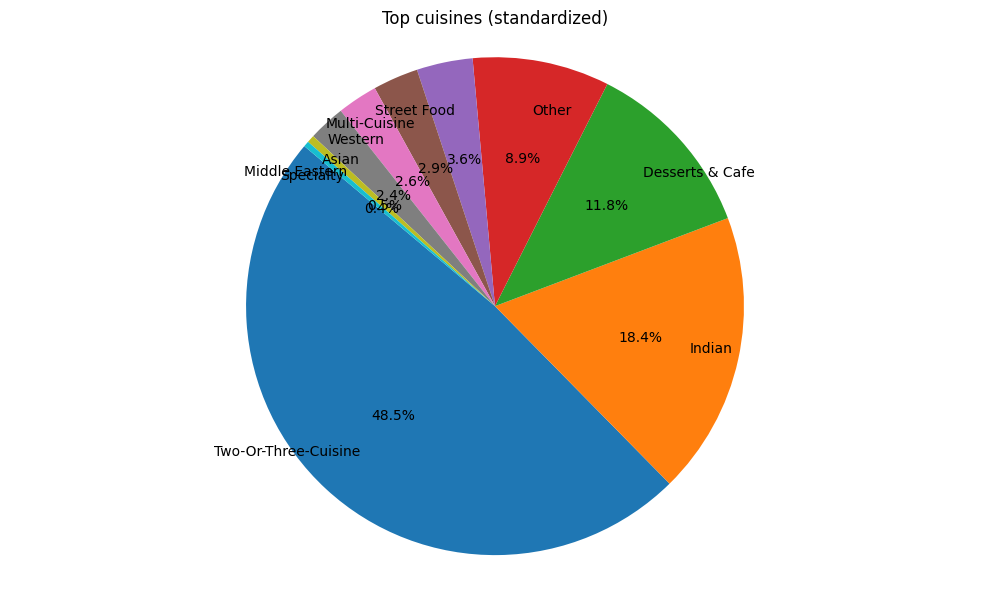

In [27]:
plot_top_cuisines_spaced_labels(df2)

### Working on 'Listed_in(type)' and 'rest_type' columns to categorize restaurant types

In [28]:
df2['listed_in(type)'].value_counts()

Delivery                                                                                                                                                                                                                     24292
Dine-out                                                                                                                                                                                                                     16240
Desserts                                                                                                                                                                                                                      3378
Cafes                                                                                                                                                                                                                         1460
Drinks & nightlife                                                                          

In [29]:
df2['listed_in(type)'].value_counts()[:7]
top7_indices = df2["listed_in(type)"].value_counts()[:7]
print(top7_indices.sum())
top7_indices

47325


Delivery              24292
Dine-out              16240
Desserts               3378
Cafes                  1460
Drinks & nightlife      751
Buffet                  689
Pubs and bars           515
Name: listed_in(type), dtype: int64

In [30]:
df2['listed_in(type)'].value_counts()[7:].sum()

4265

In [31]:
df2['listed_in(type)'].isnull().sum()   

4455

In [32]:
4455+4265

8720

In [33]:
df2['listed_in(type)'].value_counts()[:7].sum()

47325

In [34]:
# Standardize and strip the top 7 indices
top7_indices_cleaned = [str(x).strip().lower() for x in top7_indices.index]

def clean_categorical_columns(value, common_values):
    if pd.isnull(value):
        return 'Unknown'
    value_clean = str(value).strip().lower()
    if value_clean in common_values:
        return value_clean.title()  # or .capitalize() if you want only first letter capital
    else:
        return 'Unknown'



In [35]:
df2['listed_in(type)'].value_counts()[7:].count()

2770

In [36]:
df2['rest_type'].value_counts()

Quick Bites                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 19129
Casual Dining                                                                                                                                                                                                                                                                         

In [37]:
df2[df2['listed_in(type)'].isnull()]

,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
8,Yes,No,4.0/5,324,Banashankari,Cafe,Two-Or-Three-Cuisine,700,NaN
32,Yes,No,2.8/5,506,Banashankari,Quick Bites,Multi-Cuisine,500,NaN
36,Yes,No,4.2/5,415,Banashankari,Quick Bites,Two-Or-Three-Cuisine,500,NaN
41,Yes,No,4.4/5,4884,Jayanagar,Casual Dining,Two-Or-Three-Cuisine,750,NaN
48,Yes,Yes,4.6/5,2556,Banashankari,"Casual Dining, Cafe",Two-Or-Three-Cuisine,600,NaN
...,...,...,...,...,...,...,...,...,...
56226,No,Yes,4.3 /5,1776,Whitefield,"Casual Dining, Pub",Western,"1,700",NaN
56228,Yes,Yes,4.4 /5,1313,Whitefield,"Casual Dining, Bar",Asian,"1,800",NaN
56231,Yes,Yes,4.1 /5,1218,Whitefield,Pub,Two-Or-Three-Cuisine,"1,200",NaN
56233,No,Yes,4.1 /5,1003,Whitefield,"Bar, Casual Dining",Two-Or-Three-Cuisine,"1,500",NaN


In [38]:
# 1. Clean rest_type (establishment format)
def clean_rest_type(rest_type):
    """
    Standardizes restaurant type categories.
    Groups rare types into 'Unknown'.
    """
    if pd.isnull(rest_type):
        return 'Unknown'
    
    rest_type = rest_type.lower().strip()
    
    # Map common variations
    type_mapping = {
        'quick bites': 'Quick Bites',
        'casual dining': 'Casual Dining',
        'cafe': 'Cafe',
        'dessert parlor': 'Desserts',
        'dessert parlour': 'Desserts',
        'bakery': 'Bakery',
        'beverage shop': 'Beverages',
        'sweet shop': 'Desserts',
        'fine dining': 'Fine Dining',
        'bar': 'Bar',
        'pub': 'Bar',
        'lounge': 'Lounge',
        'food court': 'Food Court',
        'food truck': 'Quick Bites',
        'kiosk': 'Quick Bites'
    }
    
    for key, value in type_mapping.items():
        if key in rest_type:
            return value
    
    return 'Unknown'

# # 2. Clean listed_in(type) (service category)
# def clean_listed_type(listed_type):
#     """
#     Standardizes service/occasion categories.
#     Groups rare types into 'Other'.
#     """
#     if pd.isnull(listed_type):
#         return 'Other'
    
#     listed_type = listed_type.lower().strip()
    
#     # Map common variations
#     service_mapping = {
#         'delivery': 'Delivery',
#         'dine-out': 'Dine-out',
#         'dineout': 'Dine-out',
#         'cafes': 'Cafes',
#         'cafe': 'Cafes',
#         'desserts': 'Desserts',
#         'drinks & nightlife': 'Nightlife',
#         'nightlife': 'Nightlife',
#         'pubs and bars': 'Nightlife',
#         'buffet': 'Buffet',
#         'pocket friendly delivery': 'Delivery'
#     }
    
#     for key, value in service_mapping.items():
#         if key in listed_type:
#             return value
    
#     return 'Unknown'


In [39]:
df2["listed_in(type)"] = df2['listed_in(type)'].apply(clean_categorical_columns, common_values=top7_indices_cleaned)

In [40]:
df2['listed_in(type)'].value_counts()

Delivery              24292
Dine-Out              16240
Unknown                8720
Desserts               3378
Cafes                  1460
Drinks & Nightlife      751
Buffet                  689
Pubs And Bars           515
Name: listed_in(type), dtype: int64

In [41]:
df2['rest_type'] = df2['rest_type'].apply(clean_rest_type)

In [42]:
df2['rest_type'].value_counts()

Quick Bites      20897
Casual Dining    13050
Unknown           9603
Cafe              4490
Desserts          3146
Bar               1357
Bakery            1179
Beverages          867
Food Court         625
Lounge             423
Fine Dining        408
Name: rest_type, dtype: int64

### working with 'online_order','rate' and 'book_table' columns to analyze their impact on ratings

In [43]:
df2['online_order'].value_counts()

Yes                                                                                                                                                                                                                                                                                                                                                                                                       30428
No                                                                                                                                                                                                                                                                                                                                                                                                        21244
 ('Rated 4.0'                                                                                                                                                                                           

In [44]:
df2['online_order'].value_counts()[2:].sum()

4370

In [45]:
df2['online_order'].isnull().sum()

3

In [46]:
def clean_online_order(df):
    """
    Normalizes online_order to Yes/No.
    Fills invalid/missing values with mode.
    """
    # Normalize to Yes/No
    df["online_order"] = df["online_order"].astype(str).str.strip().str.lower()
    df["online_order"] = df["online_order"].map({"yes": "Yes", "no": "No"})
    
    # Fill NaN with mode
    mode_value = df["online_order"].mode()[0]
    df["online_order"] = df["online_order"].fillna(mode_value)
    
    return df

In [47]:
df2.columns

Index(['online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type',
       'cuisines', 'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [48]:
df2 = clean_online_order(df2)

In [49]:
df2['rate'].value_counts()[33:].sum()

7105

In [50]:
def clean_rate_column(df):
    """
    Extracts numeric ratings from various formats.
    Strategy: Extract any number found in the string, validate it's between 1-5.
    """
    def parse_rate(x):
        if pd.isna(x):
            return np.nan
        
        # Convert to lowercase string
        x = str(x).strip().lower()
        
        # Extract first number (integer or decimal)
        match = re.search(r'(\d+\.?\d*)', x)
        
        if match:
            try:
                rating = float(match.group(1))
                # Validate: ratings should be between 1 and 5
                if 1.0 <= rating <= 5.0:
                    return rating
            except:
                pass
        
        return np.nan
    
    # Apply parsing
    df["clean_rate"] = df["rate"].apply(parse_rate)
    
    # Fill NaN with location-based average
    df["clean_rate"] = df.groupby("location")["clean_rate"].transform(
        lambda x: x.fillna(x.mean())
    )
    
    # Round to one decimal place
    df["clean_rate"] = df["clean_rate"].round(1)
    
    return df

In [51]:
# Simply call the function with your dataframe
df2 = clean_rate_column(df2)

print(f"\nMissing values in clean_rate: {df2['clean_rate'].isnull().sum()}")


Missing values in clean_rate: 0


In [52]:
df2['clean_rate'].value_counts()

3.6    7566
3.8    6536
3.7    6303
3.5    5517
3.9    4464
4.0    3879
4.1    2991
3.4    2494
3.3    2306
4.2    2185
3.2    1966
4.3    1693
3.1    1561
3.0    1223
4.4    1147
2.9     802
4.5     716
2.8     600
5.0     398
2.7     307
4.6     300
2.6     260
4.7     167
1.0     139
2.5     122
2.0      98
2.4      70
4.8      66
4.9      56
2.3      51
2.2      26
2.1      24
1.5       6
1.8       5
1.3       1
Name: clean_rate, dtype: int64

In [53]:
df2.drop('rate', axis=1, inplace=True)

In [54]:
df2['online_order'].value_counts()

Yes    34801
No     21244
Name: online_order, dtype: int64

In [55]:
#Clean the book_table column
def clean_book_table(df):
    """
    Cleans book_table column:
    - Normalizes Yes/No
    - Fills missing/invalid with 'No' (since most restaurants don't offer booking)
    """
    df['book_table'] = df['book_table'].astype(str).str.strip().str.lower()
    df['book_table'] = df['book_table'].map({'yes': 'Yes', 'no': 'No'})
    
    # Fill NaN with 'No' (reasonable assumption - most don't offer table booking)
    df['book_table'] = df['book_table'].fillna('No')
    
    return df



In [56]:

df2 = clean_book_table(df2)
print(df2['book_table'].value_counts())

No     49596
Yes     6449
Name: book_table, dtype: int64


### Cleaning 'votes' column to ensure accurate representation of customer feedback

In [57]:
df2['votes'].isnull().sum()

4

In [58]:
df2['votes'].value_counts()

0                                                                                                                                                                                                                     9993
4                                                                                                                                                                                                                     1137
6                                                                                                                                                                                                                      991
7                                                                                                                                                                                                                      872
9                                                                                                                           

In [59]:
def clean_votes(df):
    """
    Converts votes to numeric for visualization.
    Handles any text values by extracting numbers.
    """
    df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
    
    # Fill missing with 0 (no votes = new/unpopular restaurant)
    df['votes'] = df['votes'].fillna(0).astype(int)
    
    return df

# Apply
df2 = clean_votes(df2)
print(df2['votes'].describe())

count    56045.000000
mean       261.766759
std        775.874706
min          0.000000
25%          0.000000
50%         32.000000
75%        172.000000
max      16832.000000
Name: votes, dtype: float64


In [60]:
df2['votes'].value_counts()

0       14366
4        1137
6         991
7         872
9         737
        ...  
3673        1
1862        1
3909        1
2155        1
843         1
Name: votes, Length: 2328, dtype: int64

### Handling 'approx_cost(for two people)' column to analyze pricing trends

In [61]:
df2['approx_cost(for two people)'].isnull().sum()

342

In [62]:
df2['approx_cost(for two people)']

0          800
1          800
2          800
3          300
4          600
         ...  
56247    1,500
56248      600
56249    2,000
56250    2,500
56251    1,500
Name: approx_cost(for two people), Length: 56045, dtype: object

In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56045 entries, 0 to 56251
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   online_order                 56045 non-null  object 
 1   book_table                   56045 non-null  object 
 2   votes                        56045 non-null  int32  
 3   location                     56045 non-null  object 
 4   rest_type                    56045 non-null  object 
 5   cuisines                     56045 non-null  object 
 6   approx_cost(for two people)  55703 non-null  object 
 7   listed_in(type)              56045 non-null  object 
 8   clean_rate                   56045 non-null  float64
dtypes: float64(1), int32(1), object(7)
memory usage: 4.1+ MB


In [64]:
def clean_approx_cost(df):
    """
    Cleans approx_cost(for two people) column:
    - Removes commas from numbers
    - Converts to numeric
    - Fills missing values with location-based median (robust to outliers)
    """
    # Remove commas and convert to numeric
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
    df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
    
    # Fill missing values with location-based median
    df['approx_cost(for two people)'] = df.groupby('location')['approx_cost(for two people)'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Convert to integer
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)
    
    return df

# Apply
df2 = clean_approx_cost(df2)
print(df2['approx_cost(for two people)'].describe())

count    53599.000000
mean       549.450083
std        430.838451
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64


C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [65]:
df2['approx_cost(for two people)'].isnull().sum()

2446